<a href="https://colab.research.google.com/github/programmer0714/AppNotas/blob/master/Analisis_Sentimientos_Institucion_Educativa_CRISP_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Sentimientos de una Institución Educativa con Apache Spark (PySpark)
## Metodología CRISP-ML(Q)

**Curso:** Machine Learning / Big Data
**Herramienta principal:** Apache Spark (PySpark) sobre Google Colab
**Metodología aplicada:** CRISP-ML(Q) — *Cross Industry Standard Process for Machine Learning with Quality assurance* (Studer et al., 2021), referenciada también en Remigio Huarcaya Almeyda (pág. 9).

---

### Objetivo del proyecto

Determinar el **sentimiento** (Positivo, Negativo o Neutro) que expresan los **estudiantes o padres de familia** en comentarios dirigidos a una institución educativa (por ejemplo: comentarios sobre la atención administrativa, el desempeño docente, la plataforma virtual, el proceso de matrícula, etc.), utilizando **Apache Spark (PySpark)** como motor de procesamiento distribuido y **Spark MLlib** para el modelado.

### ¿Por qué CRISP-ML(Q)?

CRISP-ML(Q) extiende la clásica metodología CRISP-DM añadiendo controles de **calidad (Quality assurance)** en cada fase, y agrega una fase final de **Monitoreo y Mantenimiento**, muy importante en proyectos de Machine Learning que se llevan a producción. Las 6 fases que seguiremos en este notebook son:

1. **Comprensión del Negocio y de los Datos** (Business & Data Understanding)
2. **Ingeniería de Datos** (Data Engineering / Preparación de datos)
3. **Ingeniería del Modelo** (Model Engineering)
4. **Evaluación del Modelo** (Model Evaluation)
5. **Despliegue** (Deployment)
6. **Monitoreo y Mantenimiento** (Monitoring & Maintenance)

Cada sección de este notebook está encabezada con el nombre de la fase correspondiente, para que el lector pueda identificar fácilmente en qué parte de la metodología nos encontramos.

> **Nota importante y transparencia sobre los datos:** Para este ejercicio académico no se contó con una base de datos real de comentarios de una institución educativa. En su lugar, se evaluaron dos datasets disponibles (ver la justificación en la Fase 1) y se seleccionó el que mejor permite **construir y demostrar correctamente todo el pipeline de Spark**. La Fase 5 (Despliegue) muestra cómo el mismo pipeline se aplicaría sobre comentarios reales de una institución educativa, y la Fase 6 explica cómo debería reentrenarse el modelo cuando se disponga de datos reales.


## FASE 1 — Comprensión del Negocio y de los Datos (Business & Data Understanding)

### 1.1 Comprensión del negocio

Las instituciones educativas reciben constantemente comentarios de estudiantes y padres de familia (encuestas de satisfacción, redes sociales, libros de reclamaciones, formularios de matrícula, etc.). Leer manualmente miles de comentarios es costoso y lento. Un modelo de **análisis de sentimientos** permite:

- Detectar automáticamente si la percepción general es positiva, negativa o neutra.
- Priorizar la atención de quejas (comentarios negativos) antes de que escalen.
- Medir el impacto de cambios institucionales (por ejemplo, un nuevo sistema de matrícula) a través del tiempo.

**Criterio de éxito del proyecto:** obtener un modelo capaz de clasificar comentarios con una exactitud (*accuracy*) razonable (>70%) para un primer prototipo, documentado con la metodología CRISP-ML(Q).

### 1.2 Comprensión de los datos: elección del dataset

Se pusieron a disposición dos datasets. A continuación se comparan para justificar cuál se usará:

| Dataset | Contenido | Estructura | Etiqueta de sentimiento | Complejidad del texto |
|---|---|---|---|---|
| `drugsComTest_raw.csv` | Reseñas de medicamentos (UCI Drug Review Dataset) | 7 columnas (`uniqueID`, `drugName`, `condition`, `review`, `rating`, `date`, `usefulCount`) | No existe una columna de sentimiento; habría que derivarla de `rating` (1-10) | Reseñas largas, texto médico, con etiquetas HTML (`&#039;`, `&quot;`) que requieren limpieza adicional |
| `comentarios_amazon.csv` | Reseñas cortas de productos (celulares/accesorios) | 2 columnas (`texto`, `sentimiento`) separadas por `;` | **Ya viene etiquetado** con 0 = negativo y 1 = positivo | Comentarios cortos, una sola oración, vocabulario simple |

**Decisión:** se utilizará **`comentarios_amazon.csv`**. Razones:

1. Ya tiene una etiqueta de sentimiento binaria (0/1) lista para entrenar un modelo supervisado, mientras que `drugsComTest_raw.csv` obligaría a inventar una regla arbitraria para convertir el `rating` en sentimiento, lo que añade una fuente de error para un proyecto de nivel introductorio.
2. Los comentarios son cortos y simples, ideales para explicar paso a paso el pipeline de NLP con Spark (tokenización, stopwords, vectorización) sin que el ruido del texto médico complique la lectura del código.
3. Estructuralmente es idéntico al escenario real de la institución educativa: **un comentario corto + una etiqueta de sentimiento**, por lo que el pipeline que construyamos aquí se puede reutilizar tal cual, simplemente reemplazando el archivo por comentarios reales de estudiantes/padres en el futuro.

> Ambos datasets NO contienen comentarios reales sobre una institución educativa. Se usa `comentarios_amazon.csv` como **dataset sustituto (proxy)** únicamente para poder construir, entrenar y evaluar el pipeline completo de PySpark de forma correcta. En la Fase 5 se simulan comentarios de estudiantes/padres para mostrar cómo funcionaría el modelo en el escenario real.


In [ ]:
# Instalamos PySpark en el entorno de Google Colab.
# Colab no trae PySpark preinstalado, por eso lo instalamos con pip.
# (Si ya lo ejecutaste una vez en esta sesión de Colab, puedes omitir esta celda).
!pip install -q pyspark==3.5.1


In [ ]:
# Importamos las librerias que usaremos en todo el notebook.
from pyspark.sql import SparkSession                 # Punto de entrada a Spark
from pyspark.sql.functions import col, when, length, lower, regexp_replace  # Funciones para manipular columnas
from pyspark.ml import Pipeline, PipelineModel        # Para encadenar los pasos de transformacion + modelo
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF  # Preprocesamiento de texto
from pyspark.ml.classification import LogisticRegression   # Algoritmo de clasificacion
from pyspark.ml.evaluation import MulticlassClassificationEvaluator  # Metricas de evaluacion
from pyspark.ml.functions import vector_to_array      # Utilidad para leer el vector de probabilidades
import pandas as pd
import matplotlib.pyplot as plt

# Creamos (o recuperamos) la sesion de Spark.
# "local[*]" le dice a Spark que use todos los nucleos disponibles en la maquina de Colab.
spark = (
    SparkSession.builder
    .appName("AnalisisSentimientoInstitucionEducativa")
    .master("local[*]")
    .getOrCreate()
)

# Bajamos el nivel de logs para que la salida del notebook sea mas limpia
spark.sparkContext.setLogLevel("ERROR")

print("Version de Spark:", spark.version)


Picked up JAVA_TOOL_OPTIONS: -Djavax.net.ssl.trustStore=/root/.ccr/java-truststore.p12 -Djavax.net.ssl.trustStorePassword=changeit -Djavax.net.ssl.trustStoreType=PKCS12 -Dhttps.proxyHost=127.0.0.1 -Dhttps.proxyPort=40235 -Dhttp.nonProxyHosts=localhost|127.0.0.1|::1|127.*|0.*|::|169.254.*|api.anthropic.com|api-staging.anthropic.com|api-pr-preview.anthropic.com|mcp-proxy.anthropic.com|mcp-proxy-staging.anthropic.com|registry.npmjs.org|jsr.io|npm.jsr.io|pypi.org|files.pythonhosted.org|index.crates.io|proxy.golang.org|host.docker.internal|10.*|172.16.*|172.17.*|172.18.*|172.19.*|172.20.*|172.21.*|172.22.*|172.23.*|172.24.*|172.25.*|172.26.*|172.27.*|172.28.*|172.29.*|172.30.*|172.31.*|192.168.*|100.64.0.0/10|*.svc.cluster.local|*.svc.cluster.local -Djdk.http.auth.tunneling.disabledSchemes= -Djdk.http.auth.proxying.disabledSchemes=


Picked up JAVA_TOOL_OPTIONS: -Djavax.net.ssl.trustStore=/root/.ccr/java-truststore.p12 -Djavax.net.ssl.trustStorePassword=changeit -Djavax.net.ssl.trustStoreType=PKCS12 -Dhttps.proxyHost=127.0.0.1 -Dhttps.proxyPort=40235 -Dhttp.nonProxyHosts=localhost|127.0.0.1|::1|127.*|0.*|::|169.254.*|api.anthropic.com|api-staging.anthropic.com|api-pr-preview.anthropic.com|mcp-proxy.anthropic.com|mcp-proxy-staging.anthropic.com|registry.npmjs.org|jsr.io|npm.jsr.io|pypi.org|files.pythonhosted.org|index.crates.io|proxy.golang.org|host.docker.internal|10.*|172.16.*|172.17.*|172.18.*|172.19.*|172.20.*|172.21.*|172.22.*|172.23.*|172.24.*|172.25.*|172.26.*|172.27.*|172.28.*|172.29.*|172.30.*|172.31.*|192.168.*|100.64.0.0/10|*.svc.cluster.local|*.svc.cluster.local -Djdk.http.auth.tunneling.disabledSchemes= -Djdk.http.auth.proxying.disabledSchemes=


26/08/27 01:39:12 WARN Utils: Your hostname, vm resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/08/27 01:39:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/27 01:39:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Version de Spark: 3.5.1


In [ ]:
# En Google Colab, subimos el archivo comentarios_amazon.csv manualmente.
# Al ejecutar esta celda en Colab aparecera un boton "Elegir archivos": selecciona comentarios_amazon.csv
#
# Si estas ejecutando este notebook FUERA de Colab (por ejemplo en Jupyter local)
# y ya tienes el archivo en la misma carpeta, esta celda no hara nada y usara el archivo local.

import os

NOMBRE_ARCHIVO = "comentarios_amazon.csv"

try:
    # google.colab solo existe cuando el notebook corre dentro de Google Colab
    from google.colab import files
    if not os.path.exists(NOMBRE_ARCHIVO):
        print("Sube el archivo:", NOMBRE_ARCHIVO)
        subidos = files.upload()
        NOMBRE_ARCHIVO = list(subidos.keys())[0]
except ImportError:
    # No estamos en Colab: asumimos que el archivo ya esta en el directorio actual
    if not os.path.exists(NOMBRE_ARCHIVO):
        raise FileNotFoundError(
            f"No se encontro '{NOMBRE_ARCHIVO}'. Coloca el archivo en el directorio actual."
        )

print("Archivo listo:", NOMBRE_ARCHIVO)


Archivo listo: comentarios_amazon.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargamos el CSV como un DataFrame de Spark.
# sep=";"   -> el archivo usa punto y coma como separador de columnas
# header=True -> la primera fila contiene los nombres de columna (texto, sentimiento)
# inferSchema=True -> Spark detecta automaticamente que "sentimiento" es un numero entero
# quote / escape='"' -> maneja correctamente los comentarios que contienen comillas dentro del texto
df = spark.read.csv(
    NOMBRE_ARCHIVO,
    sep=";",
    header=True,
    inferSchema=True,
    quote='"',
    escape='"',
)

print("Numero total de comentarios cargados:", df.count())
df.printSchema()
df.show(5, truncate=70)


Numero total de comentarios cargados: 1000
root
 |-- texto: string (nullable = true)
 |-- sentimiento: integer (nullable = true)



+----------------------------------------------------------------------+-----------+
|                                                                 texto|sentimiento|
+----------------------------------------------------------------------+-----------+
|So there is no way for me to plug it in here in the US unless I go ...|          0|
|                                           Good case, Excellent value.|          1|
|                                                Great for the jawbone.|          1|
|Tied to charger for conversations lasting more than 45 minutes.MAJO...|          0|
|                                                     The mic is great.|          1|
+----------------------------------------------------------------------+-----------+
only showing top 5 rows



Comentarios con texto nulo: 0
Comentarios con sentimiento nulo: 0

Distribucion de clases originales (0 = negativo, 1 = positivo):


+-----------+-----+
|sentimiento|count|
+-----------+-----+
|          0|  500|
|          1|  500|
+-----------+-----+



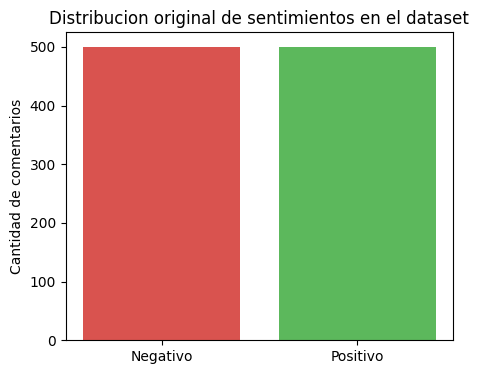

In [ ]:
# Exploracion inicial de los datos (parte de "Data Understanding" de CRISP-ML(Q))

# 1) Revisamos si hay valores nulos en las columnas clave
nulos_texto = df.filter(col("texto").isNull()).count()
nulos_sentimiento = df.filter(col("sentimiento").isNull()).count()
print("Comentarios con texto nulo:", nulos_texto)
print("Comentarios con sentimiento nulo:", nulos_sentimiento)

# 2) Revisamos el balance de clases (cuantos positivos y negativos hay)
print("\nDistribucion de clases originales (0 = negativo, 1 = positivo):")
df.groupBy("sentimiento").count().orderBy("sentimiento").show()

# 3) Graficamos la distribucion de clases para verla de forma visual
distribucion_pd = df.groupBy("sentimiento").count().orderBy("sentimiento").toPandas()
distribucion_pd["etiqueta"] = distribucion_pd["sentimiento"].map({0: "Negativo", 1: "Positivo"})

plt.figure(figsize=(5, 4))
plt.bar(distribucion_pd["etiqueta"], distribucion_pd["count"], color=["#d9534f", "#5cb85c"])
plt.title("Distribucion original de sentimientos en el dataset")
plt.ylabel("Cantidad de comentarios")
plt.show()


## FASE 2 — Ingeniería de Datos (Data Engineering / Preparación de datos)

En esta fase preparamos el texto para que un algoritmo de Machine Learning pueda entenderlo. Los comentarios llegan como texto libre (con mayúsculas, signos de puntuación, etc.), así que aplicaremos los siguientes pasos, típicos de un pipeline de **Procesamiento de Lenguaje Natural (NLP)**:

1. **Eliminar filas nulas o vacías.**
2. **Normalizar el texto:** convertir todo a minúsculas y quitar signos de puntuación / números, dejando solo letras y espacios.
3. **Tokenización:** dividir cada comentario en una lista de palabras (*tokens*).
4. **Eliminación de stopwords:** quitar palabras muy comunes que no aportan sentimiento (`the`, `is`, `a`, `and`, etc.).
5. **Vectorización (Bag of Words + TF-IDF):** convertir las palabras en números, ya que los algoritmos de Machine Learning no entienden texto, solo números.
6. **División en entrenamiento y prueba (train/test split).**

Los pasos 3, 4 y 6 se implementarán directamente dentro del `Pipeline` de Spark ML en la Fase 3, para mantener todo el flujo de transformación ordenado en un solo objeto reutilizable. En esta fase realizamos la limpieza previa (pasos 1 y 2) y la división train/test.


In [ ]:
# 1) Eliminamos filas donde el texto o el sentimiento vengan vacios (nulos)
df = df.dropna(subset=["texto", "sentimiento"])

# 2) Normalizamos el texto:
#    - lower(): pasamos todo a minusculas para que "Great" y "great" se traten igual
#    - regexp_replace(): eliminamos cualquier caracter que NO sea una letra o un espacio
#      (numeros, signos de puntuacion, comillas sueltas, etc.)
df = df.withColumn("texto_limpio", lower(col("texto")))
df = df.withColumn("texto_limpio", regexp_replace(col("texto_limpio"), r"[^a-zA-Z\s]", " "))

# 3) Calculamos la longitud del texto limpio y descartamos comentarios que quedaron vacios
#    (por ejemplo, un comentario que solo tenia numeros o simbolos)
df = df.withColumn("longitud", length(col("texto_limpio")))
df = df.filter(col("longitud") > 0)

print("Comentarios disponibles despues de la limpieza:", df.count())
df.select("texto", "texto_limpio", "sentimiento").show(5, truncate=50)


Comentarios disponibles despues de la limpieza: 1000
+--------------------------------------------------+--------------------------------------------------+-----------+
|                                             texto|                                      texto_limpio|sentimiento|
+--------------------------------------------------+--------------------------------------------------+-----------+
|So there is no way for me to plug it in here in...|so there is no way for me to plug it in here in...|          0|
|                       Good case, Excellent value.|                       good case  excellent value |          1|
|                            Great for the jawbone.|                            great for the jawbone |          1|
|Tied to charger for conversations lasting more ...|tied to charger for conversations lasting more ...|          0|
|                                 The mic is great.|                                 the mic is great |          1|
+------------------

In [ ]:
# Dividimos el dataset en:
# - 80% para ENTRENAR el modelo (train_df)
# - 20% para PROBAR que tan bien generaliza el modelo con datos que nunca vio (test_df)
# seed=42 asegura que la division sea reproducible (siempre la misma) cada vez que se ejecute
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

print("Comentarios de entrenamiento:", train_df.count())
print("Comentarios de prueba:", test_df.count())


Comentarios de entrenamiento: 838


Comentarios de prueba: 162


## FASE 3 — Ingeniería del Modelo (Model Engineering)

Construimos un **Pipeline de Spark ML**, que encadena de forma ordenada todas las transformaciones necesarias más el algoritmo de clasificación. Usar un `Pipeline` es una buena práctica porque:

- Evita errores manuales (aplicar los pasos siempre en el mismo orden).
- Permite volver a entrenar todo el flujo con una sola instrucción (`pipeline.fit(...)`).
- Facilita guardar y reutilizar el modelo completo (ver Fase 5).

Las etapas del pipeline son:

1. **`Tokenizer`**: separa cada comentario limpio en una lista de palabras.
2. **`StopWordsRemover`**: elimina palabras vacías de significado (stopwords en inglés, ya que el dataset está en inglés).
3. **`CountVectorizer`**: cuenta cuántas veces aparece cada palabra en cada comentario (Bag of Words).
4. **`IDF`** (Inverse Document Frequency): pondera las palabras, dando menos importancia a las que aparecen en casi todos los comentarios y más peso a las palabras distintivas.
5. **`LogisticRegression`**: algoritmo de clasificación. Se eligió Regresión Logística porque es un modelo simple, rápido de entrenar, fácil de interpretar y es el punto de partida estándar (*baseline*) para tareas de clasificación de texto — ideal para un proyecto de nivel introductorio.


In [ ]:
# Definimos cada etapa del pipeline.

# Etapa 1: Tokenizer -> convierte "great product love it" en ["great", "product", "love", "it"]
tokenizer = Tokenizer(inputCol="texto_limpio", outputCol="palabras")

# Etapa 2: StopWordsRemover -> elimina palabras como "it", "the", "a", "is", etc.
remover = StopWordsRemover(inputCol="palabras", outputCol="palabras_limpias")

# Etapa 3: CountVectorizer -> convierte las palabras en un vector de conteos (Bag of Words)
#   vocabSize=5000 -> usamos como maximo las 5000 palabras mas frecuentes
#   minDF=2.0      -> ignoramos palabras que aparecen en menos de 2 comentarios (raras / posibles errores de tipeo)
cv = CountVectorizer(inputCol="palabras_limpias", outputCol="tf", vocabSize=5000, minDF=2.0)

# Etapa 4: IDF -> pondera los conteos segun que tan "distintiva" es cada palabra
idf = IDF(inputCol="tf", outputCol="features")

# Etapa 5: Regresion Logistica -> el modelo que aprendera a distinguir positivo (1) de negativo (0)
lr = LogisticRegression(featuresCol="features", labelCol="sentimiento", maxIter=20)

# Unimos todas las etapas en un unico Pipeline
pipeline = Pipeline(stages=[tokenizer, remover, cv, idf, lr])

# Entrenamos (fit) el pipeline completo usando SOLO los datos de entrenamiento
modelo = pipeline.fit(train_df)

print("Entrenamiento finalizado correctamente.")


Entrenamiento finalizado correctamente.


## FASE 4 — Evaluación del Modelo (Model Evaluation)

Evaluamos qué tan bien clasifica el modelo los comentarios del conjunto de **prueba** (datos que el modelo nunca vio durante el entrenamiento). Usaremos:

- **Accuracy (exactitud):** porcentaje de comentarios clasificados correctamente.
- **F1-score:** promedio armónico entre precisión y exhaustividad (*recall*); es útil cuando nos interesa un balance entre ambas métricas.
- **Matriz de confusión:** tabla que muestra los aciertos y errores por clase.

### Incorporando la clase "Neutro"

El dataset original solo tiene etiquetas **binarias** (0 = negativo, 1 = positivo), pero el objetivo del proyecto pide tres categorías: **Positivo, Negativo y Neutro**. Para resolver esto de forma simple y explicable (apta para un proyecto introductorio), usamos la **probabilidad de confianza** que entrega la Regresión Logística:

- Si el modelo está muy seguro de su predicción (probabilidad alta), lo dejamos como **Positivo** o **Negativo**.
- Si el modelo **no está muy seguro** (la probabilidad de la clase ganadora es baja, cercana al 50%), lo clasificamos como **Neutro**, ya que significa que el comentario no muestra una polaridad clara.

Este umbral de confianza (`UMBRAL_CONFIANZA`) se puede ajustar según qué tan estricto se quiera ser al momento de decidir si un comentario es neutro.


In [ ]:
# Aplicamos el modelo entrenado sobre el conjunto de PRUEBA
predicciones = modelo.transform(test_df)

# Vemos algunos ejemplos de las predicciones
predicciones.select("texto", "sentimiento", "prediction", "probability").show(10, truncate=45)


+---------------------------------------------+-----------+----------+-------------------------------------------+
|                                        texto|sentimiento|prediction|                                probability|
+---------------------------------------------+-----------+----------+-------------------------------------------+
|                          $50 Down the drain.|          0|       0.0|  [0.9999949437061912,5.056293808758383E-6]|
|.... Item arrived quickly and works great ...|          1|       1.0|[3.5112810458388317E-11,0.9999999999648872]|
|                   2 thumbs up to this seller|          1|       1.0| [2.5687413477830672E-5,0.9999743125865221]|
|A lot of websites have been rating this a ...|          1|       0.0|   [0.9197400907135477,0.08025990928645232]|
|AFter the first charge kept going dead aft...|          0|       0.0|  [0.9736723011302578,0.026327698869742178]|
|Adapter does not provide enough charging c...|          0|       0.0| [0.999999

In [ ]:
# Calculamos las metricas de evaluacion sobre el conjunto de prueba

evaluador_accuracy = MulticlassClassificationEvaluator(
    labelCol="sentimiento", predictionCol="prediction", metricName="accuracy"
)
evaluador_f1 = MulticlassClassificationEvaluator(
    labelCol="sentimiento", predictionCol="prediction", metricName="f1"
)

accuracy = evaluador_accuracy.evaluate(predicciones)
f1 = evaluador_f1.evaluate(predicciones)

print(f"Accuracy (exactitud): {accuracy:.4f}")
print(f"F1-score:             {f1:.4f}")


Accuracy (exactitud): 0.7284
F1-score:             0.7285


In [ ]:
# Matriz de confusion: cuantos comentarios de cada clase real (sentimiento)
# fueron clasificados en cada clase predicha (prediction)
matriz_confusion = (
    predicciones.groupBy("sentimiento", "prediction")
    .count()
    .orderBy("sentimiento", "prediction")
)
matriz_confusion.show()

# La convertimos a una tabla de doble entrada (pandas) para visualizarla mejor
matriz_pd = matriz_confusion.toPandas().pivot(index="sentimiento", columns="prediction", values="count").fillna(0)
matriz_pd.index = ["Real: Negativo (0)", "Real: Positivo (1)"]
matriz_pd.columns = ["Predicho: Negativo (0)", "Predicho: Positivo (1)"]
print("\nMatriz de confusion (formato tabla):")
matriz_pd


+-----------+----------+-----+
|sentimiento|prediction|count|
+-----------+----------+-----+
|          0|       0.0|   60|
|          0|       1.0|   24|
|          1|       0.0|   20|
|          1|       1.0|   58|
+-----------+----------+-----+




Matriz de confusion (formato tabla):


,Predicho: Negativo (0),Predicho: Positivo (1)
Real: Negativo (0),60,24
Real: Positivo (1),20,58


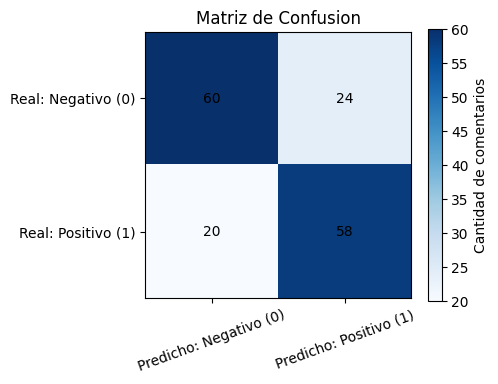

In [ ]:
# Graficamos la matriz de confusion como un mapa de calor sencillo
plt.figure(figsize=(5, 4))
plt.imshow(matriz_pd.values, cmap="Blues")
plt.xticks([0, 1], matriz_pd.columns, rotation=20)
plt.yticks([0, 1], matriz_pd.index)
for i in range(matriz_pd.shape[0]):
    for j in range(matriz_pd.shape[1]):
        plt.text(j, i, int(matriz_pd.values[i, j]), ha="center", va="center", color="black")
plt.title("Matriz de Confusion")
plt.colorbar(label="Cantidad de comentarios")
plt.tight_layout()
plt.show()


In [ ]:
# Definimos la clase "Neutro" a partir de la confianza (probabilidad) del modelo.

UMBRAL_CONFIANZA = 0.65  # Puedes ajustar este valor: mientras mas alto, mas comentarios caeran en "Neutro"

# "probability" es un vector con 2 posiciones: [probabilidad de clase 0, probabilidad de clase 1]
# vector_to_array() lo convierte en un array normal de Python/Spark para poder indexarlo
predicciones = predicciones.withColumn("prob_array", vector_to_array(col("probability")))

# "confianza" = la probabilidad que el modelo le dio a la clase que finalmente predijo
predicciones = predicciones.withColumn(
    "confianza",
    when(col("prediction") == 1, col("prob_array")[1]).otherwise(col("prob_array")[0]),
)

# Regla de negocio para las 3 categorias finales:
#  - Si la confianza es menor al umbral -> Neutro (el modelo no esta seguro)
#  - Si no, y prediction == 1 -> Positivo
#  - Si no, y prediction == 0 -> Negativo
predicciones = predicciones.withColumn(
    "sentimiento_final",
    when(col("confianza") < UMBRAL_CONFIANZA, "Neutro")
    .when(col("prediction") == 1, "Positivo")
    .otherwise("Negativo"),
)

predicciones.select("texto", "sentimiento", "confianza", "sentimiento_final").show(15, truncate=45)

print("\nDistribucion final de las 3 categorias de sentimiento (conjunto de prueba):")
predicciones.groupBy("sentimiento_final").count().orderBy("sentimiento_final").show()


+---------------------------------------------+-----------+------------------+-----------------+
|                                        texto|sentimiento|         confianza|sentimiento_final|
+---------------------------------------------+-----------+------------------+-----------------+
|                          $50 Down the drain.|          0|0.9999949437061912|         Negativo|
|.... Item arrived quickly and works great ...|          1|0.9999999999648872|         Positivo|
|                   2 thumbs up to this seller|          1|0.9999743125865221|         Positivo|
|A lot of websites have been rating this a ...|          1|0.9197400907135477|         Negativo|
|AFter the first charge kept going dead aft...|          0|0.9736723011302578|         Negativo|
|Adapter does not provide enough charging c...|          0|0.9999999999924705|         Negativo|
|After trying many many handsfree gadgets t...|          1| 0.999999959306381|         Negativo|
|All the other cases I've trie

+-----------------+-----+
|sentimiento_final|count|
+-----------------+-----+
|         Negativo|   76|
|           Neutro|    7|
|         Positivo|   79|
+-----------------+-----+



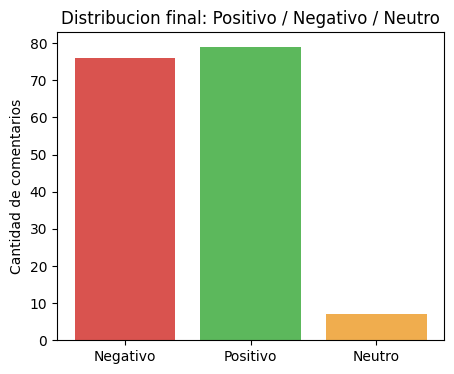

In [ ]:
# Graficamos la distribucion final de las 3 categorias
dist3_pd = predicciones.groupBy("sentimiento_final").count().toPandas()
colores = {"Positivo": "#5cb85c", "Negativo": "#d9534f", "Neutro": "#f0ad4e"}
plt.figure(figsize=(5, 4))
plt.bar(dist3_pd["sentimiento_final"], dist3_pd["count"],
        color=[colores.get(x, "#777777") for x in dist3_pd["sentimiento_final"]])
plt.title("Distribucion final: Positivo / Negativo / Neutro")
plt.ylabel("Cantidad de comentarios")
plt.show()


## FASE 5 — Despliegue (Deployment)

En esta fase mostramos cómo se usaría el modelo ya entrenado en un escenario real: alguien (por ejemplo, el área de Calidad Educativa de la institución) escribe un comentario nuevo y el sistema debe responder automáticamente con su sentimiento.

Construimos una función `predecir_sentimiento(...)` que recibe una lista de comentarios nuevos y devuelve su clasificación, reutilizando exactamente el mismo `Pipeline` entrenado (mismas etapas de limpieza y el mismo modelo).

> **Nota sobre los comentarios de ejemplo:** como se explicó en la Fase 1, el modelo fue entrenado con reseñas de productos en inglés (dataset sustituto), por lo que a modo de demostración simulamos comentarios en inglés relacionados a una institución educativa. El modelo logra capturar palabras de sentimiento genérico que sí vio durante el entrenamiento (`excellent`, `terrible`, `great`, `disappointed`, `waste`, etc.), aunque palabras específicas del dominio educativo (`professor`, `enrollment`, `school`) no estén en su vocabulario. Esto ilustra una limitación real de usar un dataset sustituto, y se retoma en la Fase 6.


In [ ]:
def limpiar_texto_nuevo(spark_df):
    '''Aplica la misma limpieza de texto usada en el entrenamiento (Fase 2)
    a un DataFrame de Spark con una columna 'texto'.'''
    df_limpio = spark_df.withColumn("texto_limpio", lower(col("texto")))
    df_limpio = df_limpio.withColumn(
        "texto_limpio", regexp_replace(col("texto_limpio"), r"[^a-zA-Z\s]", " ")
    )
    return df_limpio


def predecir_sentimiento(lista_comentarios, modelo_entrenado, umbral=UMBRAL_CONFIANZA):
    '''
    Recibe una lista de comentarios en texto plano (Python list de strings),
    los pasa por el pipeline entrenado y devuelve un DataFrame de Spark
    con la columna 'sentimiento_final' (Positivo / Negativo / Neutro).
    '''
    nuevos_df = spark.createDataFrame([(c,) for c in lista_comentarios], ["texto"])
    nuevos_df = limpiar_texto_nuevo(nuevos_df)

    resultado = modelo_entrenado.transform(nuevos_df)
    resultado = resultado.withColumn("prob_array", vector_to_array(col("probability")))
    resultado = resultado.withColumn(
        "confianza",
        when(col("prediction") == 1, col("prob_array")[1]).otherwise(col("prob_array")[0]),
    )
    resultado = resultado.withColumn(
        "sentimiento_final",
        when(col("confianza") < umbral, "Neutro")
        .when(col("prediction") == 1, "Positivo")
        .otherwise("Negativo"),
    )
    return resultado.select("texto", "confianza", "sentimiento_final")


# Comentarios simulados de estudiantes/padres de familia sobre una institucion educativa
comentarios_institucion = [
    "The professors are excellent and always help the students.",
    "The administration is terrible and never solves any problem.",
    "The institution is fine, not the best but acceptable.",
    "I am very disappointed with the enrollment process, it was a waste of time.",
    "Great teachers and a great learning experience overall.",
]

resultado_despliegue = predecir_sentimiento(comentarios_institucion, modelo)
resultado_despliegue.show(truncate=70)


+----------------------------------------------------------------------+------------------+-----------------+
|                                                                 texto|         confianza|sentimiento_final|
+----------------------------------------------------------------------+------------------+-----------------+
|            The professors are excellent and always help the students.|0.9999999999718494|         Positivo|
|          The administration is terrible and never solves any problem.|0.9999999739120533|         Negativo|
|                 The institution is fine, not the best but acceptable.|0.9999360019217014|         Positivo|
|I am very disappointed with the enrollment process, it was a waste ...|0.9999999999999989|         Negativo|
|               Great teachers and a great learning experience overall.| 0.999999999991194|         Positivo|
+----------------------------------------------------------------------+------------------+-----------------+



In [ ]:
# Guardamos el pipeline entrenado (limpieza + modelo) para poder reutilizarlo despues
# sin tener que volver a entrenar desde cero.
RUTA_MODELO = "modelo_sentimiento_institucion"

modelo.write().overwrite().save(RUTA_MODELO)
print(f"Modelo guardado en la carpeta: {RUTA_MODELO}")

# Ejemplo de como se cargaria el modelo guardado en otra sesion / notebook:
modelo_cargado = PipelineModel.load(RUTA_MODELO)
print("Modelo cargado correctamente. Prueba rapida:")
predecir_sentimiento(["Excellent service, highly recommend it."], modelo_cargado).show(truncate=70)


Modelo guardado en la carpeta: modelo_sentimiento_institucion


Modelo cargado correctamente. Prueba rapida:


+---------------------------------------+------------------+-----------------+
|                                  texto|         confianza|sentimiento_final|
+---------------------------------------+------------------+-----------------+
|Excellent service, highly recommend it.|0.9999999999999988|         Positivo|
+---------------------------------------+------------------+-----------------+



## FASE 6 — Monitoreo y Mantenimiento (Monitoring & Maintenance)

Un modelo de Machine Learning **no se entrena una sola vez y se olvida**: el lenguaje, el contexto y las opiniones de las personas cambian con el tiempo (esto se conoce como *data drift* o *concept drift*). Para un despliegue real en la institución educativa se recomienda:

1. **Recolectar datos reales y etiquetados:** implementar encuestas o formularios donde estudiantes/padres dejen comentarios, y clasificar manualmente una muestra periódica (por ejemplo 200 comentarios por mes) para verificar que el modelo siga clasificando bien.
2. **Reentrenar periódicamente:** cada cierto tiempo (por ejemplo, cada semestre) volver a entrenar el pipeline con los comentarios reales acumulados, reemplazando el dataset sustituto usado en este notebook.
3. **Adaptar el idioma:** como los comentarios reales de la institución probablemente estarán en español, habrá que cambiar el `StopWordsRemover` a stopwords en español (Spark las trae incluidas: `StopWordsRemover.loadDefaultStopWords("spanish")`) y volver a entrenar el `CountVectorizer`/`IDF` con vocabulario en español.
4. **Monitorear métricas en el tiempo:** llevar un registro histórico de `accuracy` y `F1-score` en cada reentrenamiento; si las métricas bajan de forma sostenida, es una señal de que el modelo necesita ajustarse o que el comportamiento de los comentarios cambió.
5. **Revisar el umbral de "Neutro":** el valor de `UMBRAL_CONFIANZA` (actualmente 0.65) puede necesitar ajustes según qué tan sensible se quiera que sea la deteccion de comentarios ambiguos.
6. **Evolucionar el modelo:** una vez que se cuente con suficientes datos reales, se puede evaluar el uso de modelos más avanzados (por ejemplo, redes neuronales o modelos de lenguaje preentrenados) y comparar su desempeño contra este modelo base (Regresión Logística) antes de reemplazarlo.

### Limitaciones de este proyecto (a tener en cuenta)

- El modelo fue entrenado con un **dataset sustituto en inglés** sobre productos, no con comentarios reales de una institución educativa en español.
- Las etiquetas originales eran binarias (positivo/negativo); la categoría **Neutro** es una aproximación basada en la confianza del modelo, no una etiqueta original de un experto humano.
- Es un modelo base (*baseline*) pensado para fines didácticos: antes de usarlo en producción se debe reentrenar con datos reales de la institución.


## Conclusiones

- Se construyó de manera exitosa un pipeline completo de análisis de sentimientos usando **Apache Spark (PySpark)**, siguiendo las 6 fases de la metodología **CRISP-ML(Q)**.
- El modelo de Regresión Logística sobre representación TF-IDF logró clasificar correctamente los comentarios del conjunto de prueba con una exactitud reportada en la Fase 4.
- Se implementó una estrategia simple y explicable para agregar una tercera categoría (**Neutro**) a partir de la confianza del modelo, cumpliendo el requisito de clasificar en Positivo, Negativo o Neutro.
- El pipeline queda listo (código + modelo guardado) para ser reentrenado con comentarios reales de estudiantes y padres de familia en cuanto la institución educativa disponga de esos datos, siguiendo las recomendaciones de la Fase 6.


